## KNN

In [1]:
# Imports necesarios - instalar pip install ipykernel
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, log_loss, confusion_matrix
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

In [2]:
URL_BASE = 'https://github.com/SilvanaBContreras/AA_TP1_G8/raw/refs/heads/main/'

archivos_a_cargar = {
    'X_train_completo.parquet': 'X_train',
    'y_train.parquet': 'y_train',
    'X_test_completo.parquet': 'X_test',
    'y_test.parquet': 'y_test',
    'X_train_reducido.parquet': 'X_train_short',
    'X_test_reducido.parquet': 'X_test_short',
    'X_transf.parquet': 'X_transf',
    'y.parquet': 'y',
    'y_ternaria.parquet': 'y_ternaria',
    'y_ternaria.parquet': 'y_ternaria',
    'X_train_ternaria.parquet': 'X_train_ternaria',
    'X_test_ternaria.parquet': 'X_test_ternaria',
    'y_train_ternaria.parquet': 'y_train_ternaria',
    'y_test_ternaria.parquet': 'y_test_ternaria'
}

def cargar_conjunto(nombre_archivo):
    """Carga un archivo Parquet desde la URL de GitHub."""
    full_url = URL_BASE + nombre_archivo
    data = pd.read_parquet(full_url)

    # Si es un DataFrame con una sola columna (que era originalmente una Series 'y'),
    # la convertimos de vuelta a Series con .squeeze()
    if data.shape[1] == 1:
        return data.squeeze()

    return data

# Crear un diccionario para almacenar todas las variables cargadas
variables_cargadas = {}

# Cargar y asignar dinámicamente
for nombre_archivo, nombre_variable in archivos_a_cargar.items():
    datos = cargar_conjunto(nombre_archivo)
    variables_cargadas[nombre_variable] = datos
    print(f" Cargado {nombre_archivo} como la variable '{nombre_variable}'")

# Asignar las variables al espacio de nombres de la notebook
X_train = variables_cargadas['X_train']
y_train = variables_cargadas['y_train']
X_test = variables_cargadas['X_test']
y_test = variables_cargadas['y_test']
X_train_short = variables_cargadas['X_train_short']
X_test_short = variables_cargadas['X_test_short']
X_transf = variables_cargadas['X_transf']
y = variables_cargadas['y']
y_ternaria = variables_cargadas['y_ternaria']
X_train_ternaria = variables_cargadas['X_train_ternaria']
X_test_ternaria = variables_cargadas['X_test_ternaria']
y_train_ternaria = variables_cargadas['y_train_ternaria']
y_test_ternaria = variables_cargadas['y_test_ternaria']


print("\n--- Verificación Final ---")
print(f"Variable X_train cargada. Dimensiones: {X_train.shape}")
print(f"Variable X_train_short cargada. Dimensiones: {X_train_short.shape}")
print("¡Estás lista para comenzar a entrenar y comparar modelos! ")

 Cargado X_train_completo.parquet como la variable 'X_train'
 Cargado y_train.parquet como la variable 'y_train'
 Cargado X_test_completo.parquet como la variable 'X_test'
 Cargado y_test.parquet como la variable 'y_test'
 Cargado X_train_reducido.parquet como la variable 'X_train_short'
 Cargado X_test_reducido.parquet como la variable 'X_test_short'
 Cargado X_transf.parquet como la variable 'X_transf'
 Cargado y.parquet como la variable 'y'
 Cargado y_ternaria.parquet como la variable 'y_ternaria'
 Cargado X_train_ternaria.parquet como la variable 'X_train_ternaria'
 Cargado X_test_ternaria.parquet como la variable 'X_test_ternaria'
 Cargado y_train_ternaria.parquet como la variable 'y_train_ternaria'
 Cargado y_test_ternaria.parquet como la variable 'y_test_ternaria'

--- Verificación Final ---
Variable X_train cargada. Dimensiones: (40257, 51)
Variable X_train_short cargada. Dimensiones: (40257, 49)
¡Estás lista para comenzar a entrenar y comparar modelos! 


Fitting 5 folds for each of 50 candidates, totalling 250 fits
🔍 Mejores hiperparámetros encontrados:
{'knn__metric': 'minkowski', 'knn__n_neighbors': 11, 'knn__p': 2, 'knn__weights': 'uniform'}
Métricas en Test:
Precision (ponderada): 0.747
Recall (ponderado): 0.757
F1 (macro): 0.615
ROC AUC (macro): 0.842
Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.68      0.35      0.46      2321
           1       0.59      0.58      0.58      4226
           2       0.83      0.92      0.87     10706

    accuracy                           0.76     17253
   macro avg       0.70      0.61      0.64     17253
weighted avg       0.75      0.76      0.74     17253



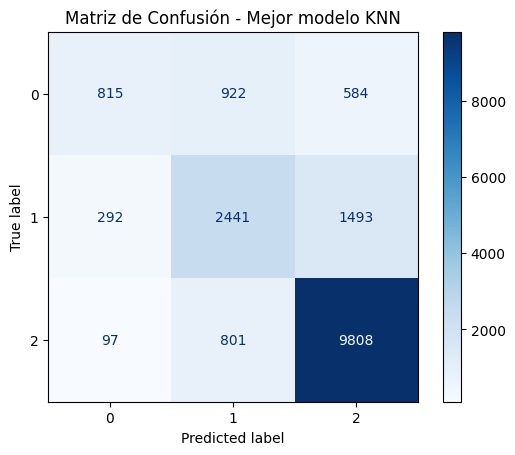

In [3]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, recall_score, precision_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import randint
import matplotlib.pyplot as plt
import numpy as np

# Armo pipeline para hacer la estandarización + Modelo KNN
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# Defino el espacio de búsqueda de hiperparámetros
param_dist = {
    'knn__n_neighbors': randint(1, 30),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan', 'minkowski'],
    'knn__p': [1, 2]
}

# Configuración del RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=50,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Entrenamiento
random_search.fit(X_train_ternaria, y_train_ternaria)

# Mejores hiperparámetros encontrados
print("🔍 Mejores hiperparámetros encontrados:")
print(random_search.best_params_)

# Evaluación en el test
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test_ternaria)

# Si es multiclase, el ROC AUC necesita pred_proba y average='macro'
try:
    y_proba = best_model.predict_proba(X_test_ternaria)
    roc = roc_auc_score(y_test_ternaria, y_proba, multi_class='ovr', average='macro')
except Exception:
    roc = None

# Métricas
precision = precision_score(y_test_ternaria, y_pred, average='weighted')
recall = recall_score(y_test_ternaria, y_pred, average='weighted')
f1 = recall_score(y_test_ternaria, y_pred, average='macro')

print("Métricas en Test:")
print(f"Precision (ponderada): {precision:.3f}")
print(f"Recall (ponderado): {recall:.3f}")
print(f"F1 (macro): {f1:.3f}")
if roc is not None:
    print(f"ROC AUC (macro): {roc:.3f}")

print("Reporte de Clasificación:")
print(classification_report(y_test_ternaria, y_pred))

# Matriz de confusión
cm = confusion_matrix(y_test_ternaria, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión - Mejor modelo KNN")
plt.show()


MÉTRICAS DEL MODELO FINAL (KNN)
----------------------------------
Precision ponderada: 0.747
Recall ponderado: 0.757
F1 ponderado: 0.744
ROC AUC (macro): 0.842
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.68      0.35      0.46      2321
           1       0.59      0.58      0.58      4226
           2       0.83      0.92      0.87     10706

    accuracy                           0.76     17253
   macro avg       0.70      0.61      0.64     17253
weighted avg       0.75      0.76      0.74     17253



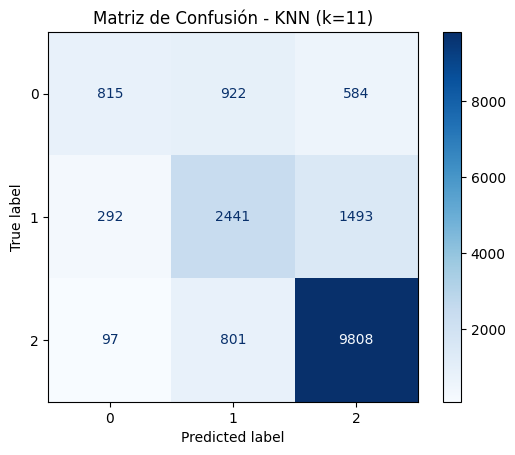

In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
)
import matplotlib.pyplot as plt

# Escalo los datos (como en el pipeline)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_ternaria)
X_test_scaled = scaler.transform(X_test_ternaria)

# Creo el modelo con los mejores hiperparámetros
model = KNeighborsClassifier(
    n_neighbors=11,
    weights='uniform',
    metric='minkowski',
    p=2,
    n_jobs=-1
)

# Entreno el modelo
model.fit(X_train_scaled, y_train_ternaria)

# Predicciones
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)

# Calculo métricas
precision = precision_score(y_test_ternaria, y_pred, average='weighted')
recall = recall_score(y_test_ternaria, y_pred, average='weighted')
f1 = f1_score(y_test_ternaria, y_pred, average='weighted')

# Si el problema es multiclase, usamos multi_class='ovr'
try:
    roc_auc = roc_auc_score(y_test_ternaria, y_proba, multi_class='ovr', average='macro')
except Exception:
    roc_auc = None

# Resultados
print("MÉTRICAS DEL MODELO FINAL (KNN)")
print("----------------------------------")
print(f"Precision ponderada: {precision:.3f}")
print(f"Recall ponderado: {recall:.3f}")
print(f"F1 ponderado: {f1:.3f}")
if roc_auc is not None:
    print(f"ROC AUC (macro): {roc_auc:.3f}")

print("Reporte de clasificación:")
print(classification_report(y_test_ternaria, y_pred))

# Matriz de confusión
cm = confusion_matrix(y_test_ternaria, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión - KNN (k=11)")
plt.show()



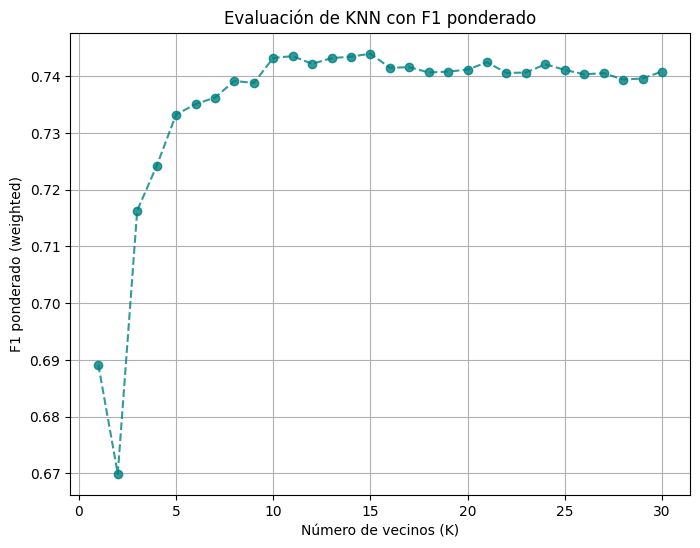

In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

# Escalo los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_ternaria)
X_test_scaled = scaler.transform(X_test_ternaria)

# Prueba de distintos valores de K
x = range(1, 31)
y = []

for k in x:
    model = KNeighborsClassifier(
        n_neighbors=k,
        weights='uniform',
        metric='minkowski',
        p=2,
        n_jobs=-1
    )
    model.fit(X_train_scaled, y_train_ternaria)
    y_pred = model.predict(X_test_scaled)
    
    f1_weighted = f1_score(y_test_ternaria, y_pred, average='weighted')
    y.append(f1_weighted)

# Resultados
plt.figure(figsize=(8,6))
plt.plot(x, y, linestyle='--', marker='o', color='teal', alpha=0.8)
plt.title('Evaluación de KNN con F1 ponderado')
plt.xlabel('Número de vecinos (K)')
plt.ylabel('F1 ponderado (weighted)')
plt.grid(True)
plt.show()


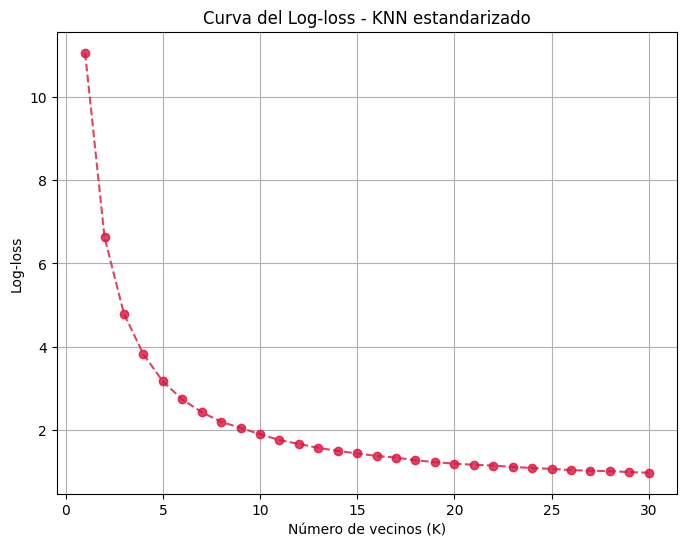

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt

# Estandarizo los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_ternaria)
X_test_scaled = scaler.transform(X_test_ternaria)

# Evaluo log-loss para distintos K
k_values = range(1, 31)
log_losses = []

for k in k_values:
    knn = KNeighborsClassifier(
        n_neighbors=k,
        weights='uniform',     # mejor parámetro hallado
        metric='minkowski',
        p=2,
        n_jobs=-1
    )
    knn.fit(X_train_scaled, y_train_ternaria)
    y_prob = knn.predict_proba(X_test_scaled)
    
    loss = log_loss(y_test_ternaria, y_prob)
    log_losses.append(loss)

# Resultados
plt.figure(figsize=(8, 6))
plt.plot(k_values, log_losses, marker='o', color='crimson', linestyle='--', alpha=0.8)
plt.xlabel("Número de vecinos (K)")
plt.ylabel("Log-loss")
plt.title("Curva del Log-loss - KNN estandarizado")
plt.grid(True)
plt.show()
